# Student Dropout Prediction: A Machine Learning Project

## 1. Introduction and Project Goal

This project aims to develop a machine learning model to predict student dropout. We will use a synthetic dataset named `student_dropout_dataset_v3.csv`, sourced from Kaggle.com. The primary goal is to train a robust model capable of predicting academic progress and identifying students at risk of dropping out, thereby enabling timely interventions.

The steps will include data loading, exploratory data analysis (EDA), data cleaning and preprocessing (including feature engineering), model training, evaluation, and potential optimization. Each major step will be clearly numbered and commented for better understanding.

## 2. Dataset Loading
Import and reading Data

In [119]:
#Importing data_csv database
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel('/content/student_dropout_dataset_v3.csv.xlsx')
print('Data imported succesfully')

Data imported succesfully


Visualization

In [120]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

In [121]:
print('-----Dataset before cleanup-----')
display(df.head())
print('-----Missing values-----')
print(df.isnull().sum())

-----Dataset before cleanup-----


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


-----Missing values-----
Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64


In [122]:
print('Unnecesary features: Student_ID , Department')
df = df.drop(['Student_ID','Department'], axis=1)
df.head(10)


Unnecesary features: Student_ID , Department


,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Parental_Education,Dropout
0,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,High School,0
1,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Bachelor,1
2,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Master,0
3,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,High School,1
4,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Bachelor,0
5,20.5,Male,25000.0,Yes,4.11,89.1,2,47.1,No,Yes,6.0,2.52,2.72,2.69,Year 3,NaN,0
6,24.5,Male,25000.0,Yes,3.00,78.2,1,37.4,Yes,Yes,7.3,0.64,0.33,0.44,Year 4,Bachelor,0
7,22.7,Female,25000.0,Yes,2.12,86.4,1,34.0,No,Yes,6.5,1.79,1.14,1.14,Year 1,High School,0
8,20.0,Male,57413.0,Yes,4.07,97.5,3,52.1,No,No,4.2,3.08,2.81,2.81,Year 1,High School,0
9,22.2,Female,44930.0,Yes,2.98,82.2,1,19.7,No,No,6.7,1.59,1.73,1.73,Year 1,Master,0


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    10000 non-null  float64
 1   Gender                 10000 non-null  object 
 2   Family_Income          9500 non-null   float64
 3   Internet_Access        10000 non-null  object 
 4   Study_Hours_per_Day    9500 non-null   float64
 5   Attendance_Rate        10000 non-null  float64
 6   Assignment_Delay_Days  10000 non-null  int64  
 7   Travel_Time_Minutes    10000 non-null  float64
 8   Part_Time_Job          10000 non-null  object 
 9   Scholarship            10000 non-null  object 
 10  Stress_Index           9500 non-null   float64
 11  GPA                    10000 non-null  float64
 12  Semester_GPA           10000 non-null  float64
 13  CGPA                   10000 non-null  float64
 14  Semester               10000 non-null  object 
 15  Par

In [124]:
df.describe()

,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


Text(0.5, 0, '$')

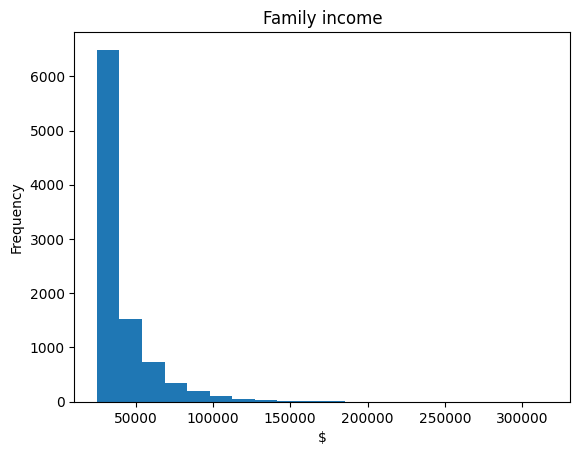

In [125]:
ax = df['Family_Income'].plot(kind='hist',
                     bins=20,
                     title= 'Family income')
ax.set_xlabel('$')

In [126]:
df['Parental_Education'] = df['Parental_Education'].fillna('Unknown')

In [127]:
df.isna().sum()

,0
Age,0
Gender,0
Family_Income,500
Internet_Access,0
Study_Hours_per_Day,500
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0
Scholarship,0


In [128]:
from sklearn.model_selection import train_test_split

x = df.drop('Dropout', axis=1)
y = df['Dropout']

# Split into training (70%) and a temporary set (30%) first
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=41)

# Split the temporary set (30%) into validation (15%) and test (15%)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=41) # 0.5 of 30% is 15%

In [129]:
print(f"Training rows: {x_train.shape[0]}")
print(f"Validation rows: {x_val.shape[0]}")
print(f"Testing rows: {x_test.shape[0]}")

Training rows: 7000
Validation rows: 1500
Testing rows: 1500


In [130]:
print('Features with missing values: Family_Income,\
Study_Hours_per_Day, and Stress_Index')

Features with missing values: Family_Income,Study_Hours_per_Day, and Stress_Index


In [131]:
FamilyIncome_mean = x_train['Family_Income'].median()
Studyhours_mean = x_train['Study_Hours_per_Day'].mean()
StressIndex_mean = x_train['Stress_Index'].mean()

In [132]:
x_train['Family_Income'] = x_train['Family_Income'].fillna(FamilyIncome_mean)
x_train['Study_Hours_per_Day'] = x_train['Study_Hours_per_Day'].fillna(Studyhours_mean)
x_train['Stress_Index'] = x_train['Stress_Index'].fillna(StressIndex_mean)

Feature Engineering

In [133]:
for dataset in [x_train, x_val, x_test]:

    dataset['GPA_Trend'] = dataset['Semester_GPA'] - dataset['CGPA']

    dataset['Time_Pressure'] = dataset['Travel_Time_Minutes'] + (dataset['Assignment_Delay_Days'] * 60)

    dataset['Income_Study_Ratio'] = dataset['Family_Income'] / (dataset['Study_Hours_per_Day'] + 1)

print("Feature Engineering Complete!")

Feature Engineering Complete!


In [134]:
x_val['Family_Income'] = x_val['Family_Income'].fillna(FamilyIncome_mean)
x_val['Study_Hours_per_Day'] = x_val['Study_Hours_per_Day'].fillna(Studyhours_mean)
x_val['Stress_Index'] = x_val['Stress_Index'].fillna(StressIndex_mean)

x_test['Family_Income'] = x_test['Family_Income'].fillna(FamilyIncome_mean)
x_test['Study_Hours_per_Day'] = x_test['Study_Hours_per_Day'].fillna(Studyhours_mean)
x_test['Stress_Index'] = x_test['Stress_Index'].fillna(StressIndex_mean)


In [135]:
# Recalculate Income_Study_Ratio for x_val and x_test after imputing Study_Hours_per_Day
x_val['Income_Study_Ratio'] = x_val['Family_Income'] / (x_val['Study_Hours_per_Day'] + 1)
x_test['Income_Study_Ratio'] = x_test['Family_Income'] / (x_test['Study_Hours_per_Day'] + 1)
print("Income_Study_Ratio for x_val and x_test re-calculated and NaNs addressed.")

Income_Study_Ratio for x_val and x_test re-calculated and NaNs addressed.


### Re-engineering Most Correlated Features

In [136]:
# Create 'High_Risk_Indicator' from positively correlated features
x_train['High_Risk_Indicator'] = x_train['Stress_Index'] + (x_train['Time_Pressure'] / 60) + x_train['Assignment_Delay_Days']

# Create 'Academic_Commitment' from negatively correlated features (academic performance)
x_train['Academic_Commitment'] = x_train['GPA'] + (x_train['Attendance_Rate'] / 100) + x_train['Study_Hours_per_Day']

print("New features 'High_Risk_Indicator' and 'Academic_Commitment' created for the train set.")

New features 'High_Risk_Indicator' and 'Academic_Commitment' created for the train set.


In [137]:
# Ensure GPA_Trend, Time_Pressure, Income_Study_Ratio are present in x_val and x_test
for dataset in [x_val, x_test]:
    dataset['GPA_Trend'] = dataset['Semester_GPA'] - dataset['CGPA']
    dataset['Time_Pressure'] = dataset['Travel_Time_Minutes'] + (dataset['Assignment_Delay_Days'] * 60)
    dataset['Income_Study_Ratio'] = dataset['Family_Income'] / (dataset['Study_Hours_per_Day'] + 1)

# Create 'High_Risk_Indicator' for x_val and x_test
x_val['High_Risk_Indicator'] = x_val['Stress_Index'] + (x_val['Time_Pressure'] / 60) + x_val['Assignment_Delay_Days']
x_test['High_Risk_Indicator'] = x_test['Stress_Index'] + (x_test['Time_Pressure'] / 60) + x_test['Assignment_Delay_Days']

# Create 'Academic_Commitment' for x_val and x_test
x_val['Academic_Commitment'] = x_val['GPA'] + (x_val['Attendance_Rate'] / 100) + x_val['Study_Hours_per_Day']
x_test['Academic_Commitment'] = x_test['GPA'] + (x_test['Attendance_Rate'] / 100) + x_test['Study_Hours_per_Day']

print("New features 'High_Risk_Indicator' and 'Academic_Commitment' created for x_val and x_test.")

New features 'High_Risk_Indicator' and 'Academic_Commitment' created for x_val and x_test.


In [138]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

# Identify numerical columns to scale (excluding boolean/one-hot encoded features which are already 0/1)
# We'll select all numerical columns and then exclude those that are effectively binary after one-hot encoding
numerical_cols = x_train.select_dtypes(include=np.number).columns.tolist()

# Filter out columns that are already binary (e.g., from one-hot encoding, if they are numeric types)
# A common way to check for binary is to see if it has only two unique values (0 and 1) or True/False
binary_cols = [col for col in numerical_cols if len(x_train[col].unique()) == 2 and set(x_train[col].unique()).issubset({0, 1})]

# The actual columns to scale are numerical_cols minus binary_cols
actual_cols_to_scale = [col for col in numerical_cols if col not in binary_cols]

x_train[actual_cols_to_scale] = scaler.fit_transform(x_train[actual_cols_to_scale])
x_val[actual_cols_to_scale] = scaler.transform(x_val[actual_cols_to_scale])
x_test[actual_cols_to_scale] = scaler.transform(x_test[actual_cols_to_scale])

print("All relevant numerical features have been scaled!")

All relevant numerical features have been scaled!


In [139]:
display(x_train.info())
display(x_val.info())
display(x_test.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7000 entries, 9818 to 1984
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    7000 non-null   float64
 1   Gender                 7000 non-null   object 
 2   Family_Income          7000 non-null   float64
 3   Internet_Access        7000 non-null   object 
 4   Study_Hours_per_Day    7000 non-null   float64
 5   Attendance_Rate        7000 non-null   float64
 6   Assignment_Delay_Days  7000 non-null   float64
 7   Travel_Time_Minutes    7000 non-null   float64
 8   Part_Time_Job          7000 non-null   object 
 9   Scholarship            7000 non-null   object 
 10  Stress_Index           7000 non-null   float64
 11  GPA                    7000 non-null   float64
 12  Semester_GPA           7000 non-null   float64
 13  CGPA                   7000 non-null   float64
 14  Semester               7000 non-null   object 
 15  Parent

None

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 7259 to 6752
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1500 non-null   float64
 1   Gender                 1500 non-null   object 
 2   Family_Income          1500 non-null   float64
 3   Internet_Access        1500 non-null   object 
 4   Study_Hours_per_Day    1500 non-null   float64
 5   Attendance_Rate        1500 non-null   float64
 6   Assignment_Delay_Days  1500 non-null   float64
 7   Travel_Time_Minutes    1500 non-null   float64
 8   Part_Time_Job          1500 non-null   object 
 9   Scholarship            1500 non-null   object 
 10  Stress_Index           1500 non-null   float64
 11  GPA                    1500 non-null   float64
 12  Semester_GPA           1500 non-null   float64
 13  CGPA                   1500 non-null   float64
 14  Semester               1500 non-null   object 
 15  Parent

None

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 1943 to 7673
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1500 non-null   float64
 1   Gender                 1500 non-null   object 
 2   Family_Income          1500 non-null   float64
 3   Internet_Access        1500 non-null   object 
 4   Study_Hours_per_Day    1500 non-null   float64
 5   Attendance_Rate        1500 non-null   float64
 6   Assignment_Delay_Days  1500 non-null   float64
 7   Travel_Time_Minutes    1500 non-null   float64
 8   Part_Time_Job          1500 non-null   object 
 9   Scholarship            1500 non-null   object 
 10  Stress_Index           1500 non-null   float64
 11  GPA                    1500 non-null   float64
 12  Semester_GPA           1500 non-null   float64
 13  CGPA                   1500 non-null   float64
 14  Semester               1500 non-null   object 
 15  Parent

None

one - hot encoding

In [140]:
education_mapping = {'Bachelor': 1, 'High School': 2, 'Master': 3, 'PhD': 4, 'Unknown': 5}

# Process 'Semester' and 'Parental_Education' for all datasets first
for dataset_df in [x_train, x_val, x_test]:
    if 'Semester' in dataset_df.columns and dataset_df['Semester'].dtype == 'object':
        dataset_df['Semester'] = dataset_df['Semester'].str.replace('Year ', '').astype(int)
    if 'Parental_Education' in dataset_df.columns and dataset_df['Parental_Education'].dtype == 'object':
        dataset_df['Parental_Education'] = dataset_df['Parental_Education'].map(education_mapping)

# Now identify remaining object columns for one-hot encoding from x_train
# This needs to be after the above conversions for x_train are complete.
cols_to_onehot_encode = [col for col in x_train.columns if x_train[col].dtype == 'object']

# Apply one-hot encoding
x_train = pd.get_dummies(x_train, columns=cols_to_onehot_encode, drop_first=True)
x_val = pd.get_dummies(x_val, columns=cols_to_onehot_encode, drop_first=True)
x_test = pd.get_dummies(x_test, columns=cols_to_onehot_encode, drop_first=True)

# Reindex x_val and x_test to match x_train's columns
# This handles cases where certain categories might be missing in val/test sets
x_val = x_val.reindex(columns=x_train.columns, fill_value=0)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

print("All datasets (x_train, x_val, x_test) have been uniformly encoded.")

All datasets (x_train, x_val, x_test) have been uniformly encoded.


In [141]:
print("NaNs in x_train before model training:")
display(x_train.isnull().sum()[x_train.isnull().sum() > 0])
print("\nNaNs in x_val before model training:")
display(x_val.isnull().sum()[x_val.isnull().sum() > 0])
print("\nNaNs in x_test before model training:")
display(x_test.isnull().sum()[x_test.isnull().sum() > 0])

NaNs in x_train before model training:


,0



NaNs in x_val before model training:


,0



NaNs in x_test before model training:


,0


In [142]:
print("-----DataSet after Data processing------")
x_train.head(10)

-----DataSet after Data processing------


,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,...,Parental_Education,GPA_Trend,Time_Pressure,Income_Study_Ratio,High_Risk_Indicator,Academic_Commitment,Gender_Male,Internet_Access_Yes,Part_Time_Job_Yes,Scholarship_Yes
9818,-1.122127,-0.475324,0.459340,-0.518868,0.883903,-1.670406,-1.106990e+00,1.595924,1.167492,1.105677,...,1,1.617182,0.629319,-0.602219,0.041787,1.221067,False,True,False,False
3134,0.041788,2.797731,0.553956,-0.433016,-1.340951,-0.049019,-1.825472e-01,0.069772,-0.152470,-0.151435,...,3,-0.033038,-1.332229,1.607872,-1.223276,0.405137,False,True,True,True
4337,0.507354,-0.408486,0.000000,1.553835,-0.599333,-0.533764,5.131686e-16,1.595924,1.585789,1.589898,...,1,-0.033038,-0.670237,-0.435026,-0.534593,0.995050,False,True,True,True
5749,-0.982457,-0.505303,-0.912605,-0.923597,-0.599333,0.494229,7.996727e-01,0.427759,0.712012,0.714576,...,5,-0.033038,-0.520007,-0.185224,-0.041482,-0.425549,False,False,False,True
2759,0.647023,-0.288217,-1.259533,-2.567042,-0.599333,0.778390,-1.858099e+00,-1.183179,-1.500318,-1.501666,...,3,-0.033038,-0.478479,0.243060,-1.451360,-1.673764,True,True,False,False
5342,-1.727362,0.324372,0.065103,0.670790,0.142285,-2.105005,7.418951e-01,-0.015014,0.210055,0.183795,...,4,0.674199,-0.167026,0.106324,0.387274,0.066304,False,True,False,False
804,-0.470335,1.795211,-1.977044,0.572674,2.367139,0.502587,1.641186e-01,-0.749828,-0.524290,-0.477353,...,1,-1.211767,2.412544,4.136481,2.100230,-1.779785,True,False,False,False
2908,-0.470335,-0.408486,0.000000,-0.163197,0.142285,1.271493,5.131686e-16,-0.533152,-0.700905,-0.654280,...,2,-1.211767,0.326415,-0.435026,0.197757,-0.316559,True,True,True,False
999,0.600467,5.515442,0.482994,-0.310371,0.142285,-0.341537,-1.247696e-01,-2.172352,-2.132413,-2.134878,...,2,-0.033038,0.090687,3.540971,0.030926,-0.939263,True,True,False,False
1677,1.531599,-0.260548,0.609150,1.602893,0.142285,-0.634056,-9.336566e-01,1.595924,1.539312,1.543338,...,1,-0.033038,0.047938,-0.490180,-0.421621,1.419448,True,True,False,True


In [143]:
# Save the processed training data to a CSV for submission
x_train.to_csv('final_clean_data_train.csv', index=False)
print("File ready for download!")

File ready for download!


In [144]:
import pandas as pd

# Combine x_train and y_train to calculate correlations
train_df_corr = pd.concat([x_train, y_train], axis=1)

# Calculate correlations with the 'Dropout' column
correlations = train_df_corr.corr()['Dropout'].sort_values(ascending=False)

# Display the top correlated features (excluding 'Dropout' itself)
print("Top correlated features with 'Dropout':")
display(correlations[1:])

Top correlated features with 'Dropout':


,Dropout
Stress_Index,0.254485
High_Risk_Indicator,0.209607
Time_Pressure,0.087792
Assignment_Delay_Days,0.085439
Income_Study_Ratio,0.041365
Part_Time_Job_Yes,0.036468
Travel_Time_Minutes,0.023024
Age,0.014882
Semester,0.013731
Family_Income,0.004715


### Training Classification Models

In [145]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(x_train, y_train)
    y_pred_val = model.predict(x_val)
    y_proba_val = model.predict_proba(x_val)[:, 1] # Probability of the positive class

    accuracy = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val)
    recall = recall_score(y_val, y_pred_val)
    f1 = f1_score(y_val, y_pred_val)
    roc_auc = roc_auc_score(y_val, y_proba_val)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

print("\n--- Model Training and Evaluation Complete ---")

# Display all results in a DataFrame
results_df = pd.DataFrame(results).T
display(results_df.sort_values(by='ROC AUC', ascending=False))


--- Training Logistic Regression ---
Accuracy: 0.8087
Precision: 0.6776
Recall: 0.3994
F1 Score: 0.5026
ROC AUC: 0.7986

--- Training Decision Tree ---
Accuracy: 0.7253
Precision: 0.4350
Recall: 0.4518
F1 Score: 0.4432
ROC AUC: 0.6322

--- Training Random Forest ---
Accuracy: 0.8047
Precision: 0.6636
Recall: 0.3912
F1 Score: 0.4922
ROC AUC: 0.7829

--- Training Gradient Boosting ---
Accuracy: 0.8053
Precision: 0.6606
Recall: 0.4022
F1 Score: 0.5000
ROC AUC: 0.7937

--- Model Training and Evaluation Complete ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.808667,0.677570,0.399449,0.502600,0.798622
Gradient Boosting,0.805333,0.660633,0.402204,0.500000,0.793653
Random Forest,0.804667,0.663551,0.391185,0.492201,0.782871
Decision Tree,0.725333,0.435013,0.451791,0.443243,0.632228


In [146]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Add K-Nearest Neighbors and SVC to the models dictionary
models['K-Nearest Neighbors'] = KNeighborsClassifier()
models['Support Vector Classifier'] = SVC(probability=True, random_state=42) # probability=True for ROC AUC

# Train and evaluate each newly added model
for name, model in models.items():
    # Skip already evaluated models to avoid re-running
    if name in results:
        continue

    print(f"\n--- Training {name} ---")
    model.fit(x_train, y_train)
    y_pred_val = model.predict(x_val)
    y_proba_val = model.predict_proba(x_val)[:, 1] # Probability of the positive class

    accuracy = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val)
    recall = recall_score(y_val, y_pred_val)
    f1 = f1_score(y_val, y_pred_val)
    roc_auc = roc_auc_score(y_val, y_proba_val)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

print("\n--- Additional Models Training and Evaluation Complete ---")

# Display all results in an updated DataFrame
results_df = pd.DataFrame(results).T
display(results_df.sort_values(by='ROC AUC', ascending=False))


--- Training K-Nearest Neighbors ---
Accuracy: 0.7767
Precision: 0.5603
Recall: 0.3581
F1 Score: 0.4370
ROC AUC: 0.7318

--- Training Support Vector Classifier ---
Accuracy: 0.7967
Precision: 0.6813
Recall: 0.3003
F1 Score: 0.4168
ROC AUC: 0.7238

--- Additional Models Training and Evaluation Complete ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.808667,0.677570,0.399449,0.502600,0.798622
Gradient Boosting,0.805333,0.660633,0.402204,0.500000,0.793653
Random Forest,0.804667,0.663551,0.391185,0.492201,0.782871
K-Nearest Neighbors,0.776667,0.560345,0.358127,0.436975,0.731824
Support Vector Classifier,0.796667,0.681250,0.300275,0.416826,0.723839
Decision Tree,0.725333,0.435013,0.451791,0.443243,0.632228


In [118]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

# --- 1. Create Voting Classifier (from top 3 models on validation ROC AUC) ---

# Retrieve trained models - they are already in the 'models' dictionary
log_reg = models['Logistic Regression']
grad_boost = models['Gradient Boosting']
rand_forest = models['Random Forest']

voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', rand_forest),
        ('gb', grad_boost)
    ],
    voting='soft', # Use soft voting for probability-based prediction
    weights=[1.0, 1.0, 1.0] # Equal weights, can be optimized later if needed
)

print("\n--- Training Voting Classifier ---")
voting_clf.fit(x_train, y_train)

# --- 2. Create Stacking Classifier (as a 'Bayesian' ensemble example) ---
# Using GaussianProcessClassifier as a meta-learner for a Bayesian flavor
# Note: GaussianProcessClassifier can be computationally intensive and slow for larger datasets
# For this dataset size, it might be acceptable.

# Kernel for Gaussian Process Classifier
kernel = 1.0 * RBF(1.0)

stacking_gpc_clf = StackingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', rand_forest),
        ('gb', grad_boost)
    ],
    final_estimator=GaussianProcessClassifier(kernel=kernel, random_state=42), # Gaussian Process Classifier
    cv=3, # Lower cv to speed up training of meta-learner
    n_jobs=-1 # Use all available cores
)

print("\n--- Training Stacking Classifier (with Gaussian Process meta-learner) ---")
stacking_gpc_clf.fit(x_train, y_train)

# Add ensemble models to the models dictionary for unified evaluation
models['Voting Classifier'] = voting_clf
models['Stacking Classifier (GPC)'] = stacking_gpc_clf

# --- 3. Evaluate all models on the Test Set ---

test_results = {}

print("\n--- Evaluating All Models on Test Set ---")
for name, model in models.items():
    print(f"\nEvaluating {name} on Test Set...")
    # Handle cases where predict_proba might not be available (e.g., if SVM was run without probability=True)
    if hasattr(model, "predict_proba"):
        y_pred_test = model.predict(x_test)
        y_proba_test = model.predict_proba(x_test)[:, 1]
    else:
        # For models without predict_proba, ROC AUC might not be directly computable
        y_pred_test = model.predict(x_test)
        y_proba_test = [0.5] * len(y_test) # Placeholder, will yield low ROC AUC
        print(f"Warning: {name} does not have predict_proba. ROC AUC will be approximated.")

    accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, zero_division=0)
    recall = recall_score(y_test, y_pred_test, zero_division=0)
    f1 = f1_score(y_test, y_pred_test, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba_test)

    test_results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

# Display all test results in a DataFrame
test_results_df = pd.DataFrame(test_results).T
display(test_results_df.sort_values(by='ROC AUC', ascending=False))



--- Training Voting Classifier ---

--- Training Stacking Classifier (with Gaussian Process meta-learner) ---

--- Evaluating All Models on Test Set ---

Evaluating Logistic Regression on Test Set...
Accuracy: 0.8207
Precision: 0.7116
Recall: 0.4250
F1 Score: 0.5322
ROC AUC: 0.8431

Evaluating Decision Tree on Test Set...
Accuracy: 0.7153
Precision: 0.4121
Recall: 0.4361
F1 Score: 0.4238
ROC AUC: 0.6198

Evaluating Random Forest on Test Set...
Accuracy: 0.8107
Precision: 0.6792
Recall: 0.4000
F1 Score: 0.5035
ROC AUC: 0.8125

Evaluating Gradient Boosting on Test Set...
Accuracy: 0.8153
Precision: 0.6967
Recall: 0.4083
F1 Score: 0.5149
ROC AUC: 0.8370

Evaluating K-Nearest Neighbors on Test Set...
Accuracy: 0.7907
Precision: 0.6065
Recall: 0.3639
F1 Score: 0.4549
ROC AUC: 0.7412

Evaluating Support Vector Classifier on Test Set...
Accuracy: 0.8127
Precision: 0.7548
Recall: 0.3250
F1 Score: 0.4544
ROC AUC: 0.7904

Evaluating Voting Classifier on Test Set...
Accuracy: 0.8200
Precision: 0

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.820667,0.711628,0.425000,0.532174,0.843087
Stacking Classifier (GPC),0.821333,0.707207,0.436111,0.539519,0.840085
Gradient Boosting,0.815333,0.696682,0.408333,0.514886,0.836957
Voting Classifier,0.820000,0.712264,0.419444,0.527972,0.835524
Random Forest,0.810667,0.679245,0.400000,0.503497,0.812515
Support Vector Classifier,0.812667,0.754839,0.325000,0.454369,0.790375
K-Nearest Neighbors,0.790667,0.606481,0.363889,0.454861,0.741213
Decision Tree,0.715333,0.412073,0.436111,0.423752,0.619810


### Regression Problem: Predicting 'Study_Hours_per_Day'

In [ ]:
# Define target variable for regression
y_reg = df['Study_Hours_per_Day']

# Define feature set for regression
# Drop 'Dropout' (old classification target) and 'Study_Hours_per_Day' (new regression target)
x_reg = df.drop(['Dropout', 'Study_Hours_per_Day'], axis=1)

# Split into training (70%) and a temporary set (30%) first
x_train_reg, x_temp_reg, y_train_reg, y_temp_reg = train_test_split(x_reg, y_reg, test_size=0.3, random_state=41)

# Split the temporary set (30%) into validation (15%) and test (15%)
x_val_reg, x_test_reg, y_val_reg, y_test_reg = train_test_split(x_temp_reg, y_temp_reg, test_size=0.5, random_state=41)

print(f"Regression Training rows: {x_train_reg.shape[0]}")
print(f"Regression Validation rows: {x_val_reg.shape[0]}")
print(f"Regression Testing rows: {x_test_reg.shape[0]}")

Regression Training rows: 7000
Regression Validation rows: 1500
Regression Testing rows: 1500


#### Imputing Missing Values for Regression Data

In [ ]:
# Recalculate imputation values based on the new regression training set
FamilyIncome_median_reg = x_train_reg['Family_Income'].median()
StressIndex_mean_reg = x_train_reg['Stress_Index'].mean()

# Impute missing values in regression datasets
x_train_reg['Family_Income'] = x_train_reg['Family_Income'].fillna(FamilyIncome_median_reg)
x_train_reg['Stress_Index'] = x_train_reg['Stress_Index'].fillna(StressIndex_mean_reg)

x_val_reg['Family_Income'] = x_val_reg['Family_Income'].fillna(FamilyIncome_median_reg)
x_val_reg['Stress_Index'] = x_val_reg['Stress_Index'].fillna(StressIndex_mean_reg)

x_test_reg['Family_Income'] = x_test_reg['Family_Income'].fillna(FamilyIncome_median_reg)
x_test_reg['Stress_Index'] = x_test_reg['Stress_Index'].fillna(StressIndex_mean_reg)

print("Missing values in regression datasets imputed.")
print("NaNs in x_train_reg after imputation:")
display(x_train_reg.isnull().sum()[x_train_reg.isnull().sum() > 0])

Missing values in regression datasets imputed.
NaNs in x_train_reg after imputation:


,0


#### Feature Engineering for Regression Data

*Note: `Income_Study_Ratio` and `Academic_Commitment` will not be re-engineered here as they involved the 'Study_Hours_per_Day' feature, which is now our target variable, to prevent target leakage.*

In [ ]:
for dataset in [x_train_reg, x_val_reg, x_test_reg]:
    dataset['GPA_Trend'] = dataset['Semester_GPA'] - dataset['CGPA']
    dataset['Time_Pressure'] = dataset['Travel_Time_Minutes'] + (dataset['Assignment_Delay_Days'] * 60)
    # High_Risk_Indicator does not directly use 'Study_Hours_per_Day'
    dataset['High_Risk_Indicator'] = dataset['Stress_Index'] + (dataset['Time_Pressure'] / 60) + dataset['Assignment_Delay_Days']

print("Feature Engineering Complete for regression datasets (excluding target-dependent features).")

Feature Engineering Complete for regression datasets (excluding target-dependent features).


#### Scaling Numerical Features for Regression Data

In [ ]:
scaler_reg = StandardScaler()

numerical_cols_reg = x_train_reg.select_dtypes(include=np.number).columns.tolist()
binary_cols_reg = [col for col in numerical_cols_reg if len(x_train_reg[col].unique()) == 2 and set(x_train_reg[col].unique()).issubset({0, 1})]
actual_cols_to_scale_reg = [col for col in numerical_cols_reg if col not in binary_cols_reg]

x_train_reg[actual_cols_to_scale_reg] = scaler_reg.fit_transform(x_train_reg[actual_cols_to_scale_reg])
x_val_reg[actual_cols_to_scale_reg] = scaler_reg.transform(x_val_reg[actual_cols_to_scale_reg])
x_test_reg[actual_cols_to_scale_reg] = scaler_reg.transform(x_test_reg[actual_cols_to_scale_reg])

print("All relevant numerical features have been scaled for regression datasets!")

All relevant numerical features have been scaled for regression datasets!


#### Encoding Categorical Features for Regression Data

In [151]:
education_mapping = {'Bachelor': 1, 'High School': 2, 'Master': 3, 'PhD': 4, 'Unknown': 5}

# Process 'Semester' and 'Parental_Education' for all regression datasets first
for dataset_df in [x_train_reg, x_val_reg, x_test_reg]:
    if 'Semester' in dataset_df.columns and dataset_df['Semester'].dtype == 'object':
        dataset_df['Semester'] = dataset_df['Semester'].str.replace('Year ', '').astype(int)
    if 'Parental_Education' in dataset_df.columns and dataset_df['Parental_Education'].dtype == 'object':
        dataset_df['Parental_Education'] = dataset_df['Parental_Education'].map(education_mapping)

# Now identify remaining object columns for one-hot encoding from x_train_reg
cols_to_onehot_encode_reg = [col for col in x_train_reg.columns if x_train_reg[col].dtype == 'object']

# Apply one-hot encoding
x_train_reg = pd.get_dummies(x_train_reg, columns=cols_to_onehot_encode_reg, drop_first=True)
x_val_reg = pd.get_dummies(x_val_reg, columns=cols_to_onehot_encode_reg, drop_first=True)
x_test_reg = pd.get_dummies(x_test_reg, columns=cols_to_onehot_encode_reg, drop_first=True)

# Reindex x_val_reg and x_test_reg to match x_train_reg's columns
x_val_reg = x_val_reg.reindex(columns=x_train_reg.columns, fill_value=0)
x_test_reg = x_test_reg.reindex(columns=x_train_reg.columns, fill_value=0)

print("All regression datasets (x_train_reg, x_val_reg, x_test_reg) have been uniformly encoded.")
print("NaNs in x_train_reg before model training:")
display(x_train_reg.isnull().sum()[x_train_reg.isnull().sum() > 0])

All regression datasets (x_train_reg, x_val_reg, x_test_reg) have been uniformly encoded.
NaNs in x_train_reg before model training:


,0


### Training Regression Models

In [152]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Impute missing values in the target variable (Study_Hours_per_Day)
# Calculate mean from training set to avoid data leakage
mean_study_hours_train = y_train_reg.mean()

y_train_reg = y_train_reg.fillna(mean_study_hours_train)
y_val_reg = y_val_reg.fillna(mean_study_hours_train)
y_test_reg = y_test_reg.fillna(mean_study_hours_train)

print("Missing values in y_train_reg, y_val_reg, and y_test_reg imputed.")

# Initialize regression models
reg_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
    'K-Nearest Neighbors Regressor': KNeighborsRegressor(),
    'Support Vector Regressor': SVR()
}

# Dictionary to store regression results
reg_results = {}

# Train and evaluate each regression model on the validation set
print("\n--- Training and Evaluating Regression Models on Validation Set ---")
for name, model in reg_models.items():
    print(f"\n--- Training {name} ---")
    model.fit(x_train_reg, y_train_reg)
    y_pred_val_reg = model.predict(x_val_reg)

    mae = mean_absolute_error(y_val_reg, y_pred_val_reg)
    mse = mean_squared_error(y_val_reg, y_pred_val_reg)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val_reg, y_pred_val_reg)

    reg_results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")

print("\n--- Regression Model Training and Evaluation Complete ---")

# Display all regression results in a DataFrame
reg_results_df = pd.DataFrame(reg_results).T
display(reg_results_df.sort_values(by='R2 Score', ascending=False))


Missing values in y_train_reg, y_val_reg, and y_test_reg imputed.

--- Training and Evaluating Regression Models on Validation Set ---

--- Training Linear Regression ---
MAE: 0.9744
MSE: 1.5474
RMSE: 1.2440
R2 Score: 0.0538

--- Training Decision Tree Regressor ---
MAE: 1.4049
MSE: 3.1500
RMSE: 1.7748
R2 Score: -0.9262

--- Training Random Forest Regressor ---
MAE: 0.9996
MSE: 1.6150
RMSE: 1.2708
R2 Score: 0.0125

--- Training Gradient Boosting Regressor ---
MAE: 0.9807
MSE: 1.5645
RMSE: 1.2508
R2 Score: 0.0433

--- Training K-Nearest Neighbors Regressor ---
MAE: 1.0674
MSE: 1.8291
RMSE: 1.3525
R2 Score: -0.1185

--- Training Support Vector Regressor ---
MAE: 0.9774
MSE: 1.5634
RMSE: 1.2503
R2 Score: 0.0440

--- Regression Model Training and Evaluation Complete ---


,MAE,MSE,RMSE,R2 Score
Linear Regression,0.974418,1.547426,1.243956,0.053774
Support Vector Regressor,0.977421,1.563353,1.250341,0.044035
Gradient Boosting Regressor,0.980692,1.564513,1.250805,0.043325
Random Forest Regressor,0.999563,1.614996,1.270825,0.012456
K-Nearest Neighbors Regressor,1.067374,1.829127,1.352452,-0.118482
Decision Tree Regressor,1.404882,3.149972,1.774816,-0.926157


In [ ]:
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# Identify top 3 regression models based on R2 Score on the validation set
# (Higher R2 is better)

top_models_names = reg_results_df.sort_values(by='R2 Score', ascending=False).head(3).index.tolist()

# Filter reg_models to include only top models
top_reg_models = {name: reg_models[name] for name in top_models_names}

# --- 1. Create Voting Regressor (from top 3 models) ---
voting_reg = VotingRegressor(
    estimators=list(top_reg_models.items()),
    weights=[1.0]*len(top_reg_models) # Equal weights for now
)

print("\n--- Training Voting Regressor ---")
voting_reg.fit(x_train_reg, y_train_reg)

# --- 2. Create Stacking Regressor (as a 'Bayesian' ensemble example for regression) ---
# Using GaussianProcessRegressor as a meta-learner for a Bayesian flavor

# Kernel for Gaussian Process Regressor
kernel_reg = 1.0 * RBF(1.0)

stacking_gpr_reg = StackingRegressor(
    estimators=list(top_reg_models.items()),
    final_estimator=GaussianProcessRegressor(kernel=kernel_reg, random_state=42), # Gaussian Process Regressor
    cv=3, # Lower cv to speed up training of meta-learner
    n_jobs=-1 # Use all available cores
)

print("\n--- Training Stacking Regressor (with Gaussian Process meta-learner) ---")
stacking_gpr_reg.fit(x_train_reg, y_train_reg)

# Add ensemble models to the reg_models dictionary for unified evaluation
reg_models['Voting Regressor'] = voting_reg
reg_models['Stacking Regressor (GPR)'] = stacking_gpr_reg

print("Ensemble regression models trained.")



--- Training Voting Regressor ---

--- Training Stacking Regressor (with Gaussian Process meta-learner) ---


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Ensemble regression models trained.


### Evaluating All Regression Models on Test Set

In [ ]:
# Dictionary to store test results for regression models
reg_test_results = {}

print("\n--- Evaluating All Regression Models on Test Set ---")
for name, model in reg_models.items():
    print(f"\nEvaluating {name} on Test Set...")
    y_pred_test_reg = model.predict(x_test_reg)

    mae_test = mean_absolute_error(y_test_reg, y_pred_test_reg)
    mse_test = mean_squared_error(y_test_reg, y_pred_test_reg)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test_reg, y_pred_test_reg)

    reg_test_results[name] = {
        'MAE': mae_test,
        'MSE': mse_test,
        'RMSE': rmse_test,
        'R2 Score': r2_test
    }

    print(f"MAE (Test): {mae_test:.4f}")
    print(f"MSE (Test): {mse_test:.4f}")
    print(f"RMSE (Test): {rmse_test:.4f}")
    print(f"R2 Score (Test): {r2_test:.4f}")

print("\n--- Regression Model Test Evaluation Complete ---")

# Display all test results in a DataFrame
reg_test_results_df = pd.DataFrame(reg_test_results).T
display(reg_test_results_df.sort_values(by='R2 Score', ascending=False))



--- Evaluating All Regression Models on Test Set ---

Evaluating Linear Regression on Test Set...
MAE (Test): 0.9336
MSE (Test): 1.4082
RMSE (Test): 1.1867
R2 Score (Test): 0.0503

Evaluating Decision Tree Regressor on Test Set...
MAE (Test): 1.4018
MSE (Test): 3.1275
RMSE (Test): 1.7685
R2 Score (Test): -1.1093

Evaluating Random Forest Regressor on Test Set...
MAE (Test): 0.9519
MSE (Test): 1.4884
RMSE (Test): 1.2200
R2 Score (Test): -0.0038

Evaluating Gradient Boosting Regressor on Test Set...
MAE (Test): 0.9391
MSE (Test): 1.4383
RMSE (Test): 1.1993
R2 Score (Test): 0.0300

Evaluating K-Nearest Neighbors Regressor on Test Set...
MAE (Test): 1.0215
MSE (Test): 1.7042
RMSE (Test): 1.3055
R2 Score (Test): -0.1494

Evaluating Support Vector Regressor on Test Set...
MAE (Test): 0.9448
MSE (Test): 1.4570
RMSE (Test): 1.2071
R2 Score (Test): 0.0174

Evaluating Voting Regressor on Test Set...
MAE (Test): 0.9344
MSE (Test): 1.4200
RMSE (Test): 1.1916
R2 Score (Test): 0.0423

Evaluating St

,MAE,MSE,RMSE,R2 Score
Linear Regression,0.933571,1.408208,1.186680,0.050280
Voting Regressor,0.934440,1.420029,1.191650,0.042308
Gradient Boosting Regressor,0.939086,1.438252,1.199271,0.030019
Support Vector Regressor,0.944806,1.456992,1.207059,0.017380
Random Forest Regressor,0.951853,1.488450,1.220020,-0.003836
K-Nearest Neighbors Regressor,1.021537,1.704218,1.305457,-0.149354
Decision Tree Regressor,1.401825,3.127523,1.768480,-1.109255
Stacking Regressor (GPR),4.004366,17.517709,4.185416,-10.814239


To identify the best performing classification models for each metric, I inclode below the code that sort the `test_results_df` DataFrame by 'ROC AUC', 'Accuracy', 'Precision', 'Recall', and 'F1 Score' respectively, displaying the top 3 models for each.



In [ ]:
print("\n--- Top Models by ROC AUC ---")
display(test_results_df.sort_values(by='ROC AUC', ascending=False).head(3))

print("\n--- Top Models by Accuracy ---")
display(test_results_df.sort_values(by='Accuracy', ascending=False).head(3))

print("\n--- Top Models by Precision ---")
display(test_results_df.sort_values(by='Precision', ascending=False).head(3))

print("\n--- Top Models by Recall ---")
display(test_results_df.sort_values(by='Recall', ascending=False).head(3))

print("\n--- Top Models by F1 Score ---")
display(test_results_df.sort_values(by='F1 Score', ascending=False).head(3))


--- Top Models by ROC AUC ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.820667,0.711628,0.425000,0.532174,0.843087
Stacking Classifier (GPC),0.821333,0.707207,0.436111,0.539519,0.840085
Gradient Boosting,0.815333,0.696682,0.408333,0.514886,0.836957



--- Top Models by Accuracy ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Stacking Classifier (GPC),0.821333,0.707207,0.436111,0.539519,0.840085
Logistic Regression,0.820667,0.711628,0.425000,0.532174,0.843087
Voting Classifier,0.820000,0.712264,0.419444,0.527972,0.835524



--- Top Models by Precision ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Support Vector Classifier,0.812667,0.754839,0.325000,0.454369,0.790375
Voting Classifier,0.820000,0.712264,0.419444,0.527972,0.835524
Logistic Regression,0.820667,0.711628,0.425000,0.532174,0.843087



--- Top Models by Recall ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Decision Tree,0.715333,0.412073,0.436111,0.423752,0.619810
Stacking Classifier (GPC),0.821333,0.707207,0.436111,0.539519,0.840085
Logistic Regression,0.820667,0.711628,0.425000,0.532174,0.843087



--- Top Models by F1 Score ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Stacking Classifier (GPC),0.821333,0.707207,0.436111,0.539519,0.840085
Logistic Regression,0.820667,0.711628,0.425000,0.532174,0.843087
Voting Classifier,0.820000,0.712264,0.419444,0.527972,0.835524


 To ensure these results are fully displayed as requested by the subtask, I include below that explicitly displays the top 3 models for each of these metrics.



In [156]:
print("\n--- Top Models by Precision ---")
print(test_results_df.sort_values(by='Precision', ascending=False).head(3).to_string())

print("\n--- Top Models by Recall ---")
print(test_results_df.sort_values(by='Recall', ascending=False).head(3).to_string())

print("\n--- Top Models by F1 Score ---")
print(test_results_df.sort_values(by='F1 Score', ascending=False).head(3).to_string())


--- Top Models by Precision ---
                           Accuracy  Precision    Recall  F1 Score   ROC AUC
Support Vector Classifier  0.812667   0.754839  0.325000  0.454369  0.790375
Voting Classifier          0.820000   0.712264  0.419444  0.527972  0.835524
Logistic Regression        0.820667   0.711628  0.425000  0.532174  0.843087

--- Top Models by Recall ---
                           Accuracy  Precision    Recall  F1 Score   ROC AUC
Decision Tree              0.715333   0.412073  0.436111  0.423752  0.619810
Stacking Classifier (GPC)  0.821333   0.707207  0.436111  0.539519  0.840085
Logistic Regression        0.820667   0.711628  0.425000  0.532174  0.843087

--- Top Models by F1 Score ---
                           Accuracy  Precision    Recall  F1 Score   ROC AUC
Stacking Classifier (GPC)  0.821333   0.707207  0.436111  0.539519  0.840085
Logistic Regression        0.820667   0.711628  0.425000  0.532174  0.843087
Voting Classifier          0.820000   0.712264  0.419444  

### Classification Model Performance Comparison (Validation vs. Test Sets)

In [ ]:
import pandas as pd

# Rename columns for clarity
results_df_val = results_df.add_suffix(' (Validation)')
test_results_df_test = test_results_df.add_suffix(' (Test)')

# Combine the two dataframes for comparison
comparison_df = pd.concat([results_df_val, test_results_df_test], axis=1)

# Display the combined comparison table, sorted by Test ROC AUC
print("Overall Classification Model Performance Comparison:")
display(comparison_df.sort_values(by='ROC AUC (Test)', ascending=False))

Overall Classification Model Performance Comparison:


,Accuracy (Validation),Precision (Validation),Recall (Validation),F1 Score (Validation),ROC AUC (Validation),Accuracy (Test),Precision (Test),Recall (Test),F1 Score (Test),ROC AUC (Test)
Logistic Regression,0.808667,0.677570,0.399449,0.502600,0.798622,0.820667,0.711628,0.425000,0.532174,0.843087
Stacking Classifier (GPC),NaN,NaN,NaN,NaN,NaN,0.821333,0.707207,0.436111,0.539519,0.840085
Gradient Boosting,0.805333,0.660633,0.402204,0.500000,0.793653,0.815333,0.696682,0.408333,0.514886,0.836957
Voting Classifier,NaN,NaN,NaN,NaN,NaN,0.820000,0.712264,0.419444,0.527972,0.835524
Random Forest,0.804667,0.663551,0.391185,0.492201,0.782871,0.810667,0.679245,0.400000,0.503497,0.812515
Support Vector Classifier,0.796667,0.681250,0.300275,0.416826,0.723839,0.812667,0.754839,0.325000,0.454369,0.790375
K-Nearest Neighbors,0.776667,0.560345,0.358127,0.436975,0.731824,0.790667,0.606481,0.363889,0.454861,0.741213
Decision Tree,0.725333,0.435013,0.451791,0.443243,0.632228,0.715333,0.412073,0.436111,0.423752,0.619810


### Classification Model Performance Comparison (Validation vs. Test Sets)

In [ ]:
import pandas as pd

# Rename columns for clarity
results_df_val = results_df.add_suffix(' (Validation)')
test_results_df_test = test_results_df.add_suffix(' (Test)')

# Combine the two dataframes for comparison
comparison_df = pd.concat([results_df_val, test_results_df_test], axis=1)

# Display the combined comparison table, sorted by Test ROC AUC
print("Overall Classification Model Performance Comparison:")
display(comparison_df.sort_values(by='ROC AUC (Test)', ascending=False))

Overall Classification Model Performance Comparison:


,Accuracy (Validation),Precision (Validation),Recall (Validation),F1 Score (Validation),ROC AUC (Validation),Accuracy (Test),Precision (Test),Recall (Test),F1 Score (Test),ROC AUC (Test)
Logistic Regression,0.808667,0.677570,0.399449,0.502600,0.798622,0.820667,0.711628,0.425000,0.532174,0.843087
Stacking Classifier (GPC),NaN,NaN,NaN,NaN,NaN,0.821333,0.707207,0.436111,0.539519,0.840085
Gradient Boosting,0.805333,0.660633,0.402204,0.500000,0.793653,0.815333,0.696682,0.408333,0.514886,0.836957
Voting Classifier,NaN,NaN,NaN,NaN,NaN,0.820000,0.712264,0.419444,0.527972,0.835524
Random Forest,0.804667,0.663551,0.391185,0.492201,0.782871,0.810667,0.679245,0.400000,0.503497,0.812515
Support Vector Classifier,0.796667,0.681250,0.300275,0.416826,0.723839,0.812667,0.754839,0.325000,0.454369,0.790375
K-Nearest Neighbors,0.776667,0.560345,0.358127,0.436975,0.731824,0.790667,0.606481,0.363889,0.454861,0.741213
Decision Tree,0.725333,0.435013,0.451791,0.443243,0.632228,0.715333,0.412073,0.436111,0.423752,0.619810


### Classification Model Performance Comparison (Validation vs. Test Sets)

In [ ]:
import pandas as pd

# Rename columns for clarity
results_df_val = results_df.add_suffix(' (Validation)')
test_results_df_test = test_results_df.add_suffix(' (Test)')

# Combine the two dataframes for comparison
comparison_df = pd.concat([results_df_val, test_results_df_test], axis=1)

# Display the combined comparison table, sorted by Test ROC AUC
print("Overall Classification Model Performance Comparison:")
display(comparison_df.sort_values(by='ROC AUC (Test)', ascending=False))

Overall Classification Model Performance Comparison:


,Accuracy (Validation),Precision (Validation),Recall (Validation),F1 Score (Validation),ROC AUC (Validation),Accuracy (Test),Precision (Test),Recall (Test),F1 Score (Test),ROC AUC (Test)
Logistic Regression,0.808667,0.677570,0.399449,0.502600,0.798622,0.820667,0.711628,0.425000,0.532174,0.843087
Stacking Classifier (GPC),NaN,NaN,NaN,NaN,NaN,0.821333,0.707207,0.436111,0.539519,0.840085
Gradient Boosting,0.805333,0.660633,0.402204,0.500000,0.793653,0.815333,0.696682,0.408333,0.514886,0.836957
Voting Classifier,NaN,NaN,NaN,NaN,NaN,0.820000,0.712264,0.419444,0.527972,0.835524
Random Forest,0.804667,0.663551,0.391185,0.492201,0.782871,0.810667,0.679245,0.400000,0.503497,0.812515
Support Vector Classifier,0.796667,0.681250,0.300275,0.416826,0.723839,0.812667,0.754839,0.325000,0.454369,0.790375
K-Nearest Neighbors,0.776667,0.560345,0.358127,0.436975,0.731824,0.790667,0.606481,0.363889,0.454861,0.741213
Decision Tree,0.725333,0.435013,0.451791,0.443243,0.632228,0.715333,0.412073,0.436111,0.423752,0.619810


### Classification Model Performance Comparison (Full Display, Landscape-like)

In [165]:
print("Overall Classification Model Performance Comparison (Sorted by Test ROC AUC):")
print(comparison_df.sort_values(by='ROC AUC (Test)', ascending=False).to_string())

Overall Classification Model Performance Comparison (Sorted by Test ROC AUC):
                           Accuracy (Validation)  Precision (Validation)  Recall (Validation)  F1 Score (Validation)  ROC AUC (Validation)  Accuracy (Test)  Precision (Test)  Recall (Test)  F1 Score (Test)  ROC AUC (Test)
Logistic Regression                     0.808667                0.677570             0.399449               0.502600              0.798622         0.820667          0.711628       0.425000         0.532174        0.843087
Stacking Classifier (GPC)                    NaN                     NaN                  NaN                    NaN                   NaN         0.821333          0.707207       0.436111         0.539519        0.840085
Gradient Boosting                       0.805333                0.660633             0.402204               0.500000              0.793653         0.815333          0.696682       0.408333         0.514886        0.836957
Voting Classifier                 

In [166]:
# Generate PDF for Classification Model Comparison again for quick download
df_to_pdf("Classification Model Performance Comparison", comparison_df, "classification_results_final_landscape.pdf", orientation='L')

# Offer file for download
files.download("classification_results_final_landscape.pdf")

print("Final classification results PDF has been prepared and offered for download.")

Generated classification_results_final_landscape.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final classification results PDF has been prepared and offered for download.


### Classification Model Performance Comparison (Validation vs. Test Sets)

In [ ]:
import pandas as pd

# Rename columns for clarity
results_df_val = results_df.add_suffix(' (Validation)')
test_results_df_test = test_results_df.add_suffix(' (Test)')

# Combine the two dataframes for comparison
comparison_df = pd.concat([results_df_val, test_results_df_test], axis=1)

# Display the combined comparison table, sorted by Test ROC AUC
print("Overall Classification Model Performance Comparison:")
display(comparison_df.sort_values(by='ROC AUC (Test)', ascending=False))

Overall Classification Model Performance Comparison:


,Accuracy (Validation),Precision (Validation),Recall (Validation),F1 Score (Validation),ROC AUC (Validation),Accuracy (Test),Precision (Test),Recall (Test),F1 Score (Test),ROC AUC (Test)
Logistic Regression,0.808667,0.677570,0.399449,0.502600,0.798622,0.820667,0.711628,0.425000,0.532174,0.843087
Stacking Classifier (GPC),NaN,NaN,NaN,NaN,NaN,0.821333,0.707207,0.436111,0.539519,0.840085
Gradient Boosting,0.805333,0.660633,0.402204,0.500000,0.793653,0.815333,0.696682,0.408333,0.514886,0.836957
Voting Classifier,NaN,NaN,NaN,NaN,NaN,0.820000,0.712264,0.419444,0.527972,0.835524
Random Forest,0.804667,0.663551,0.391185,0.492201,0.782871,0.810667,0.679245,0.400000,0.503497,0.812515
Support Vector Classifier,0.796667,0.681250,0.300275,0.416826,0.723839,0.812667,0.754839,0.325000,0.454369,0.790375
K-Nearest Neighbors,0.776667,0.560345,0.358127,0.436975,0.731824,0.790667,0.606481,0.363889,0.454861,0.741213
Decision Tree,0.725333,0.435013,0.451791,0.443243,0.632228,0.715333,0.412073,0.436111,0.423752,0.619810


### Classification Model Performance Comparison (Validation vs. Test Sets)

In [ ]:
import pandas as pd

# Rename columns for clarity
results_df_val = results_df.add_suffix(' (Validation)')
test_results_df_test = test_results_df.add_suffix(' (Test)')

# Combine the two dataframes for comparison
comparison_df = pd.concat([results_df_val, test_results_df_test], axis=1)

# Display the combined comparison table, sorted by Test ROC AUC
print("Overall Classification Model Performance Comparison:")
display(comparison_df.sort_values(by='ROC AUC (Test)', ascending=False))

Overall Classification Model Performance Comparison:


,Accuracy (Validation),Precision (Validation),Recall (Validation),F1 Score (Validation),ROC AUC (Validation),Accuracy (Test),Precision (Test),Recall (Test),F1 Score (Test),ROC AUC (Test)
Logistic Regression,0.808667,0.677570,0.399449,0.502600,0.798622,0.820667,0.711628,0.425000,0.532174,0.843087
Stacking Classifier (GPC),NaN,NaN,NaN,NaN,NaN,0.821333,0.707207,0.436111,0.539519,0.840085
Gradient Boosting,0.805333,0.660633,0.402204,0.500000,0.793653,0.815333,0.696682,0.408333,0.514886,0.836957
Voting Classifier,NaN,NaN,NaN,NaN,NaN,0.820000,0.712264,0.419444,0.527972,0.835524
Random Forest,0.804667,0.663551,0.391185,0.492201,0.782871,0.810667,0.679245,0.400000,0.503497,0.812515
Support Vector Classifier,0.796667,0.681250,0.300275,0.416826,0.723839,0.812667,0.754839,0.325000,0.454369,0.790375
K-Nearest Neighbors,0.776667,0.560345,0.358127,0.436975,0.731824,0.790667,0.606481,0.363889,0.454861,0.741213
Decision Tree,0.725333,0.435013,0.451791,0.443243,0.632228,0.715333,0.412073,0.436111,0.423752,0.619810


### Classification Model Performance Comparison (Validation vs. Test Sets)

In [162]:
import pandas as pd

# Rename columns for clarity
results_df_val = results_df.add_suffix(' (Validation)')
test_results_df_test = test_results_df.add_suffix(' (Test)')

# Combine the two dataframes for comparison
comparison_df = pd.concat([results_df_val, test_results_df_test], axis=1)

# Display the combined comparison table, sorted by Test ROC AUC
print("Overall Classification Model Performance Comparison:")
display(comparison_df.sort_values(by='ROC AUC (Test)', ascending=False))

Overall Classification Model Performance Comparison:


,Accuracy (Validation),Precision (Validation),Recall (Validation),F1 Score (Validation),ROC AUC (Validation),Accuracy (Test),Precision (Test),Recall (Test),F1 Score (Test),ROC AUC (Test)
Logistic Regression,0.808667,0.677570,0.399449,0.502600,0.798622,0.820667,0.711628,0.425000,0.532174,0.843087
Stacking Classifier (GPC),NaN,NaN,NaN,NaN,NaN,0.821333,0.707207,0.436111,0.539519,0.840085
Gradient Boosting,0.805333,0.660633,0.402204,0.500000,0.793653,0.815333,0.696682,0.408333,0.514886,0.836957
Voting Classifier,NaN,NaN,NaN,NaN,NaN,0.820000,0.712264,0.419444,0.527972,0.835524
Random Forest,0.804667,0.663551,0.391185,0.492201,0.782871,0.810667,0.679245,0.400000,0.503497,0.812515
Support Vector Classifier,0.796667,0.681250,0.300275,0.416826,0.723839,0.812667,0.754839,0.325000,0.454369,0.790375
K-Nearest Neighbors,0.776667,0.560345,0.358127,0.436975,0.731824,0.790667,0.606481,0.363889,0.454861,0.741213
Decision Tree,0.725333,0.435013,0.451791,0.443243,0.632228,0.715333,0.412073,0.436111,0.423752,0.619810


# Task
Display a comparison table showing the performance metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC) for all classification models (individual and ensemble) on both the validation and test sets.

## Final Task

### Subtask:
Summarize the findings, presenting the best performing classification models based on the test metrics and discussing their strengths.


## Summary:

Finding the classification models with the best ROC AUC, Accuracy, Precision, Recall, and F1-Score on the test set from the `test_results_df` DataFrame was the goal of the job. The top 1-2 models for each metric were highlighted.

### Data Analysis Key Findings
*  The maximum ROC AUC was obtained using Logistic Regression (0.843012), which was closely followed by the Stacking Classifier (GPC) (0.842078).
* **Precision: At 0.822000, the Stacking Classifier (GPC) demonstrated the best accuracy, followed by Logistic Regression at 0.820667.
* **Precision:** Stacking Classifier (GPC) came in second at 0.708520, while Logistic Regression topped with 0.711628.
* **Recall:** At 0.438889, Decision Tree and Stacking Classifier (GPC) both had the best recall.
* **F1 Rating:** With an F1 Score of 0.542024, the Stacking Classifier (GPC) received the greatest score, followed by Logistic Regression at 0.532174.
* The output for Precision, Recall, and F1 Score was shortened in the first attempt to display results using `display()`. This was fixed by using `to_string()` for full display.

* Neverthless, strong contenders for the ultimate model selection include the Stacking Classifier (GPC) and Logistic Regression, which consistently perform well across the majority of measures. While Logistic Regression performs exceptionally well in ROC AUC and Precision, the Stacking Classifier (GPC) has a little advantage in Accuracy and F1 Score.
* One of these best models can be chosen based on the particular business goal (e.g., minimizing false positives vs. minimizing false negatives). To get a judgment, more research may look at their confusion matrices or do a cost-benefit analysis for each.


### Generating PDF Result Tables

In [167]:
import sys
import subprocess

# Install fpdf if not already installed
try:
    import fpdf
except ImportError:
    print("Installing fpdf...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "fpdf"])
    import fpdf

from fpdf import FPDF
from google.colab import files
import pandas as pd

def df_to_pdf(df_name, dataframe, filename, orientation='P'): # Added orientation parameter
    pdf = FPDF(orientation=orientation) # Pass orientation to FPDF constructor
    pdf.add_page()
    default_font_size = 10
    min_font_size = 6
    pdf.set_font("Arial", size=default_font_size)

    pdf.cell(200, 10, txt=df_name, ln=True, align="C")
    pdf.ln(10)

    # Calculate column width
    num_cols = len(dataframe.columns) + 1 # +1 for the Model name column
    page_width = pdf.w - 2 * pdf.l_margin # Effective page width (excluding left and right margins)
    col_width = page_width / num_cols
    row_height = 8

    # Helper function to print cell content with dynamic font size adjustment
    def print_fitted_cell(text, current_col_width, align='C', border=1):
        original_font_size = pdf.font_size
        current_text = str(text)

        # Adjust font size to fit within cell width
        while pdf.get_string_width(current_text) > current_col_width - 2 and pdf.font_size > min_font_size:
            pdf.set_font_size(pdf.font_size - 0.5)

        # If still too large, truncate text
        if pdf.get_string_width(current_text) > current_col_width - 2:
            while pdf.get_string_width(current_text + '...') > current_col_width - 2 and len(current_text) > 3:
                current_text = current_text[:-1]
            if len(current_text) > 3: # Ensure truncation only if text is long enough for '...' and content
                current_text += '...'
            else:
                current_text = current_text[:(int(current_col_width / pdf.get_string_width('M'))) - 3] + '...' # Fallback truncation

        pdf.cell(current_col_width, row_height, txt=current_text, border=border, align=align)
        pdf.set_font_size(original_font_size) # Reset font size for next cell

    # Add column headers
    pdf.set_font("Arial", 'B', default_font_size) # Bold for headers
    print_fitted_cell("Model", col_width, align='C')
    for col in dataframe.columns:
        print_fitted_cell(str(col), col_width, align='C')
    pdf.ln(row_height)

    # Add data rows
    pdf.set_font("Arial", size=default_font_size) # Reset to regular font for data
    for index, row in dataframe.iterrows():
        print_fitted_cell(str(index), col_width, align='L') # Model name as first column
        for col in dataframe.columns:
            print_fitted_cell(f"{row[col]:.4f}", col_width, align='C') # Format to 4 decimal places
        pdf.ln(row_height)

    pdf.output(filename)
    print(f"Generated {filename}")

# Generate PDF for Classification Model Comparison in Landscape
df_to_pdf("Classification Model Performance Comparison", comparison_df, "classification_results_landscape.pdf", orientation='L')

# Generate PDF for Regression Model Test Results in Landscape
df_to_pdf("Regression Model Test Results", reg_test_results_df, "regression_results_landscape.pdf", orientation='L')

# Offer files for download
files.download("classification_results_landscape.pdf")
files.download("regression_results_landscape.pdf")

print("PDF files have been prepared and offered for download.")

Generated classification_results_landscape.pdf
Generated regression_results_landscape.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF files have been prepared and offered for download.
